#**IMPORT LIBRARIES**

In [ ]:
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)

##Display Settings

In [ ]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',100)
pd.set_option('display.width',120)

##Visualization Style

In [ ]:
sns.set_theme(style='darkgrid')

#**LOAD DATASET**

In [ ]:
health_connect = pd.read_csv('HealthConnect_Appointment_Data.csv')

In [ ]:
print(health_connect.head())

  appointment_id patient_id  gender  age age_group         appointment_type booking_date appointment_date  \
0       HC-00001     P-1613  Female   39     35-44                Follow-up     2/6/2025        2/18/2025   
1       HC-00002     P-0813    Male   31     25-34  Specialist Consultation    2/25/2026        2/27/2026   
2       HC-00003     P-1366  Female   50     45-54     General Consultation   11/16/2025       12/24/2025   
3       HC-00004     P-1031    Male   59     55-64                Follow-up    7/18/2025        8/28/2025   
4       HC-00005     P-1458  Female   34     25-34                Follow-up     7/9/2025        8/25/2025   

  appointment_day appointment_time  booking_lead_days  previous_appointments  previous_no_shows reminder_sent  \
0         Tuesday        Afternoon                 12                      2                  0           Yes   
1          Friday          Morning                  2                      6                  0           Yes   
2     

#**Dataset Overview**

In [ ]:
print(health_connect.shape)
print('\nColumn names:')
for number, column in enumerate(health_connect.columns, 1):
  print(f'{number}. {column}')

(5000, 18)

Column names:
1. appointment_id
2. patient_id
3. gender
4. age
5. age_group
6. appointment_type
7. booking_date
8. appointment_date
9. appointment_day
10. appointment_time
11. booking_lead_days
12. previous_appointments
13. previous_no_shows
14. reminder_sent
15. reminder_channel
16. distance_to_clinic_km
17. waiting_time_minutes
18. appointment_outcome


#**Data Types**

In [ ]:
data_types = pd.DataFrame({'Column': health_connect.columns, 'Data Type': health_connect.dtypes.astype(str).values,'Uniques Values':[health_connect[column].nunique(dropna=True) for column in health_connect.columns],'Missing Values':[health_connect[column].isna().sum() for column in health_connect.columns]})
display(data_types)

,Column,Data Type,Uniques Values,Missing Values
0,appointment_id,object,5000,0
1,patient_id,object,1696,0
2,gender,object,3,0
3,age,int64,63,0
4,age_group,object,6,0
5,appointment_type,object,4,0
6,booking_date,object,593,0
7,appointment_date,object,545,0
8,appointment_day,object,7,0
9,appointment_time,object,3,0


**Data Types:** Variables such as Age, Booking Lead Days, and Previous no shows are stored as integers; Distance to clinic and waiting time in minutes are stored as decimals, while the rest are stored as texts.

**Missing Values:** Reminder channel column has 1366 missing values, distance to clinic has 90 missing values, and waiting time has 60 missing values



#**CONFIRM TARGET VARIABLE**

In [ ]:
outcome_col = 'appointment_outcome'
if outcome_col not in health_connect.columns:
    raise KeyError(f"{outcome_col} was not found in the dataset.")

print("Confirmed target variable:",outcome_col)
print("\nTarget values:")
display(health_connect[outcome_col].value_counts(dropna=False).to_frame("Count"))

Confirmed target variable: appointment_outcome

Target values:


,Count
appointment_outcome,
No-Show,2423
Attended,2314
Cancelled,263


#**APPOINTMENT OUTCOME ANALYSIS**

In [ ]:
outcome_summary = pd.DataFrame({"Count": health_connect[outcome_col].value_counts(dropna=False),
    "Percentage": (health_connect[outcome_col].value_counts(normalize=True,dropna=False).mul(100).round(2))})
display(outcome_summary)

,Count,Percentage
appointment_outcome,,
No-Show,2423,48.46
Attended,2314,46.28
Cancelled,263,5.26


#CREATING MODELLING DATASET

In [ ]:
model_outcomes = ['Attended','No-Show']
model_health_connect = health_connect[health_connect['appointment_outcome'].isin(model_outcomes)].copy()
model_health_connect['no_show'] = (model_health_connect['appointment_outcome']== 'No-Show').astype(int)
print('Health Connect:',len(health_connect))
print('Rows used for modelling:',len(model_health_connect))
print('Rows excluded:',len(health_connect)-len(model_health_connect))
print("\nModelling target distribution:")

target_summary = pd.DataFrame({"Count": model_health_connect["no_show"].value_counts(),"Percentage": (model_health_connect["no_show"].value_counts(normalize=True).mul(100).round(2))})
target_summary.index = ["Attended","No-Show"]
display(target_summary)

Health Connect: 5000
Rows used for modelling: 4737
Rows excluded: 263

Modelling target distribution:


,Count,Percentage
Attended,2423,51.15
No-Show,2314,48.85


#**Duplicate Analysis**

In [ ]:
duplicate_count = model_health_connect.duplicated().sum()
print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:",round(duplicate_count / len(model_health_connect) * 100,2),"%")

Duplicate rows: 0
Duplicate percentage: 0.0 %


There are no duplicates

#**Missing Value Analysis**

In [ ]:
missing_summary = pd.DataFrame({"Column": model_health_connect.columns,"Missing Count": [model_health_connect[column].isna().sum()
        for column in model_health_connect.columns],"Missing Percentage": [round(model_health_connect[column].isna().mean() * 100,2)
        for column in model_health_connect.columns]})
missing_summary = missing_summary.sort_values("Missing Percentage",ascending=False)
display(missing_summary)

,Column,Missing Count,Missing Percentage
14,reminder_channel,1285,27.13
15,distance_to_clinic_km,86,1.82
16,waiting_time_minutes,58,1.22
2,gender,0,0.00
1,patient_id,0,0.00
0,appointment_id,0,0.00
3,age,0,0.00
7,appointment_date,0,0.00
4,age_group,0,0.00
5,appointment_type,0,0.00


Missing Values: Reminder channel column has 1285 missing values, distance to clinic has 86 missing values, and waiting time has 58 missing values

In [ ]:
means = {'distance_to_clinic_km':model_health_connect['distance_to_clinic_km'].mean(),'waiting_time_minutes':model_health_connect['waiting_time_minutes'].mean()}
model_health_connect = model_health_connect.fillna(value = means)

#**CATEGORICAL VALUE INSPECTION**

In [ ]:
categorical_columns = model_health_connect.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("Categorical columns:")
print(categorical_columns)
for column in categorical_columns:
    print("\n" + "=" * 80)
    print(f"Column: {column}")
    print("Unique values:",model_health_connect[column].nunique(dropna=True))
    value_counts = (model_health_connect[column].value_counts(dropna=False).to_frame("Count"))
    value_counts["Percentage"] = (value_counts["Count"]/ len(model_health_connect)* 100).round(2)
    display(value_counts)

Categorical columns:
['appointment_id', 'patient_id', 'gender', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel', 'appointment_outcome']

Column: appointment_id
Unique values: 4737


,Count,Percentage
appointment_id,,
HC-05000,1,0.02
HC-04984,1,0.02
HC-04983,1,0.02
HC-04982,1,0.02
HC-04981,1,0.02
...,...,...
HC-00006,1,0.02
HC-00005,1,0.02
HC-00004,1,0.02



Column: patient_id
Unique values: 1680


,Count,Percentage
patient_id,,
P-1399,9,0.19
P-1776,9,0.19
P-1742,9,0.19
P-0869,8,0.17
P-0599,8,0.17
...,...,...
P-0228,1,0.02
P-1540,1,0.02
P-0703,1,0.02



Column: gender
Unique values: 3


...

,Count,Percentage
reminder_sent,,
Yes,3452,72.87
No,1285,27.13



Column: reminder_channel
Unique values: 3


,Count,Percentage
reminder_channel,,
SMS,1907,40.26
NaN,1285,27.13
WhatsApp,1039,21.93
Email,506,10.68



Column: appointment_outcome
Unique values: 2


,Count,Percentage
appointment_outcome,,
No-Show,2423,51.15
Attended,2314,48.85


#**STANDARDIZE TEXT VALUES**

In [ ]:
for column in categorical_columns:
    if model_health_connect[column].dtype == "object":
        model_health_connect[column] = (model_health_connect[column].astype("string").str.strip())
print("Leading/trailing whitespace has been removed ""from text variables.")

Leading/trailing whitespace has been removed from text variables.


##**RECHECKING CATEGORICAL VALUES**

In [ ]:
for column in categorical_columns:
    print("\n" + "=" * 80)
    print(f"Column: {column}")
    display(model_health_connect[column].value_counts(dropna=False).to_frame("Count"))


Column: appointment_id


,Count
appointment_id,
HC-00002,1
HC-04985,1
HC-04986,1
HC-04987,1
HC-04988,1
...,...
HC-04980,1
HC-04981,1
HC-04982,1



Column: patient_id


,Count
patient_id,
P-1399,9
P-1742,9
P-1776,9
P-0887,8
P-1104,8
...,...
P-0228,1
P-0050,1
P-0748,1



Column: gender


...

,Count
reminder_sent,
Yes,3452
No,1285



Column: reminder_channel


,Count
reminder_channel,
SMS,1907
<NA>,1285
WhatsApp,1039
Email,506



Column: appointment_outcome


,Count
appointment_outcome,
No-Show,2423
Attended,2314


#**RARE AND HIGH CARDINALITY ANALYSIS**

In [ ]:
RARE_THRESHOLD = 1.0
HIGH_CARDINALITY_THRESHOLD = 50
cardinality_report = []
for column in categorical_columns:
    counts = model_health_connect[column].value_counts(normalize=True,dropna=False) * 100
    rare_values = counts[counts < RARE_THRESHOLD]
    unique_count = model_health_connect[column].nunique(dropna=True)
    if unique_count >= HIGH_CARDINALITY_THRESHOLD:
        cardinality_flag = "High"
    else:
        cardinality_flag = "Normal"
    cardinality_report.append({"Column": column,"Unique Values": unique_count,"Rare Categories (<1%)": len(rare_values),"Rare Category Percentage": round(rare_values.sum(),2),"Cardinality Flag": cardinality_flag})
cardinality_report = pd.DataFrame(cardinality_report)
display(cardinality_report)

,Column,Unique Values,Rare Categories (<1%),Rare Category Percentage,Cardinality Flag
0,appointment_id,4737,4737,100.0,High
1,patient_id,1680,1680,100.0,High
2,gender,3,0,0.0,Normal
3,age_group,6,0,0.0,Normal
4,appointment_type,4,0,0.0,Normal
5,booking_date,592,592,100.0,High
6,appointment_date,545,545,100.0,High
7,appointment_day,7,0,0.0,Normal
8,appointment_time,3,0,0.0,Normal
9,reminder_sent,2,0,0.0,Normal


#**IDENTIFY POTENTIAL IDENTIFIER COLUMNS**

In [ ]:
import re
identifier_keywords = ["id","identifier","reference","number","code"]
potential_identifier_columns = []
for column in model_health_connect.columns:
    normalized = re.sub(r"[^a-z0-9]","",str(column).lower())
    if any(keyword in normalized
        for keyword in identifier_keywords):
      potential_identifier_columns.append(column)
print("Potential identifier columns:")
for column in potential_identifier_columns:
    print("-", column)

Potential identifier columns:
- appointment_id
- patient_id


#**NUMERICAL ANALYSIS**

In [ ]:
numeric_columns = model_health_connect.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns:")
for column in numeric_columns:
    print("-", column)
if numeric_columns:
    display(model_health_connect[numeric_columns].describe().T)

Numerical columns:
- age
- booking_lead_days
- previous_appointments
- previous_no_shows
- distance_to_clinic_km
- waiting_time_minutes
- no_show


,count,mean,std,min,25%,50%,75%,max
age,4737.0,48.719443,18.147296,18.0,33.0,49.0,64.0,80.0
booking_lead_days,4737.0,29.639012,17.412842,0.0,15.0,30.0,45.0,60.0
previous_appointments,4737.0,3.023433,1.744586,0.0,2.0,3.0,4.0,11.0
previous_no_shows,4737.0,0.551193,0.750821,0.0,0.0,0.0,1.0,5.0
distance_to_clinic_km,4737.0,10.109460,6.553854,0.5,5.3,8.8,13.3,45.0
waiting_time_minutes,4737.0,24.244069,10.811668,2.0,17.0,24.0,32.0,68.0
no_show,4737.0,0.511505,0.499920,0.0,0.0,1.0,1.0,1.0


#**NEGATIVE VALUE CHECK**

In [ ]:
negative_value_report = []
for column in numeric_columns:
    negative_count = (model_health_connect[column] < 0).sum()
    negative_value_report.append({"Column": column,"Negative Values": negative_count,"Negative Percentage": round(negative_count / len(model_health_connect) * 100,2)})
negative_value_report = pd.DataFrame(negative_value_report)
display(negative_value_report)


,Column,Negative Values,Negative Percentage
0,age,0,0.0
1,booking_lead_days,0,0.0
2,previous_appointments,0,0.0
3,previous_no_shows,0,0.0
4,distance_to_clinic_km,0,0.0
5,waiting_time_minutes,0,0.0
6,no_show,0,0.0


#**OUTLIER DETECTION**

In [ ]:
outlier_summary = []
for column in numeric_columns:
    Q1 = model_health_connect[column].quantile(0.25)
    Q3 = model_health_connect[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_mask = ((model_health_connect[column] < lower_bound) |(model_health_connect[column] > upper_bound))
    outlier_count = outlier_mask.sum()
    outlier_summary.append({"Column": column,"Q1": Q1,"Q3": Q3,"IQR": IQR,"Lower Bound": lower_bound,"Upper Bound": upper_bound,"Outlier Count": outlier_count,"Outlier Percentage": round(outlier_count / len(model_health_connect) * 100,2)})

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary.sort_values("Outlier Percentage",ascending=False))

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
4,distance_to_clinic_km,5.3,13.3,8.0,-6.7,25.3,151,3.19
3,previous_no_shows,0.0,1.0,1.0,-1.5,2.5,91,1.92
2,previous_appointments,2.0,4.0,2.0,-1.0,7.0,61,1.29
5,waiting_time_minutes,17.0,32.0,15.0,-5.5,54.5,17,0.36
0,age,33.0,64.0,31.0,-13.5,110.5,0,0.00
1,booking_lead_days,15.0,45.0,30.0,-30.0,90.0,0,0.00
6,no_show,0.0,1.0,1.0,-1.5,2.5,0,0.00


#**OUTLIER VISUALIZATION**

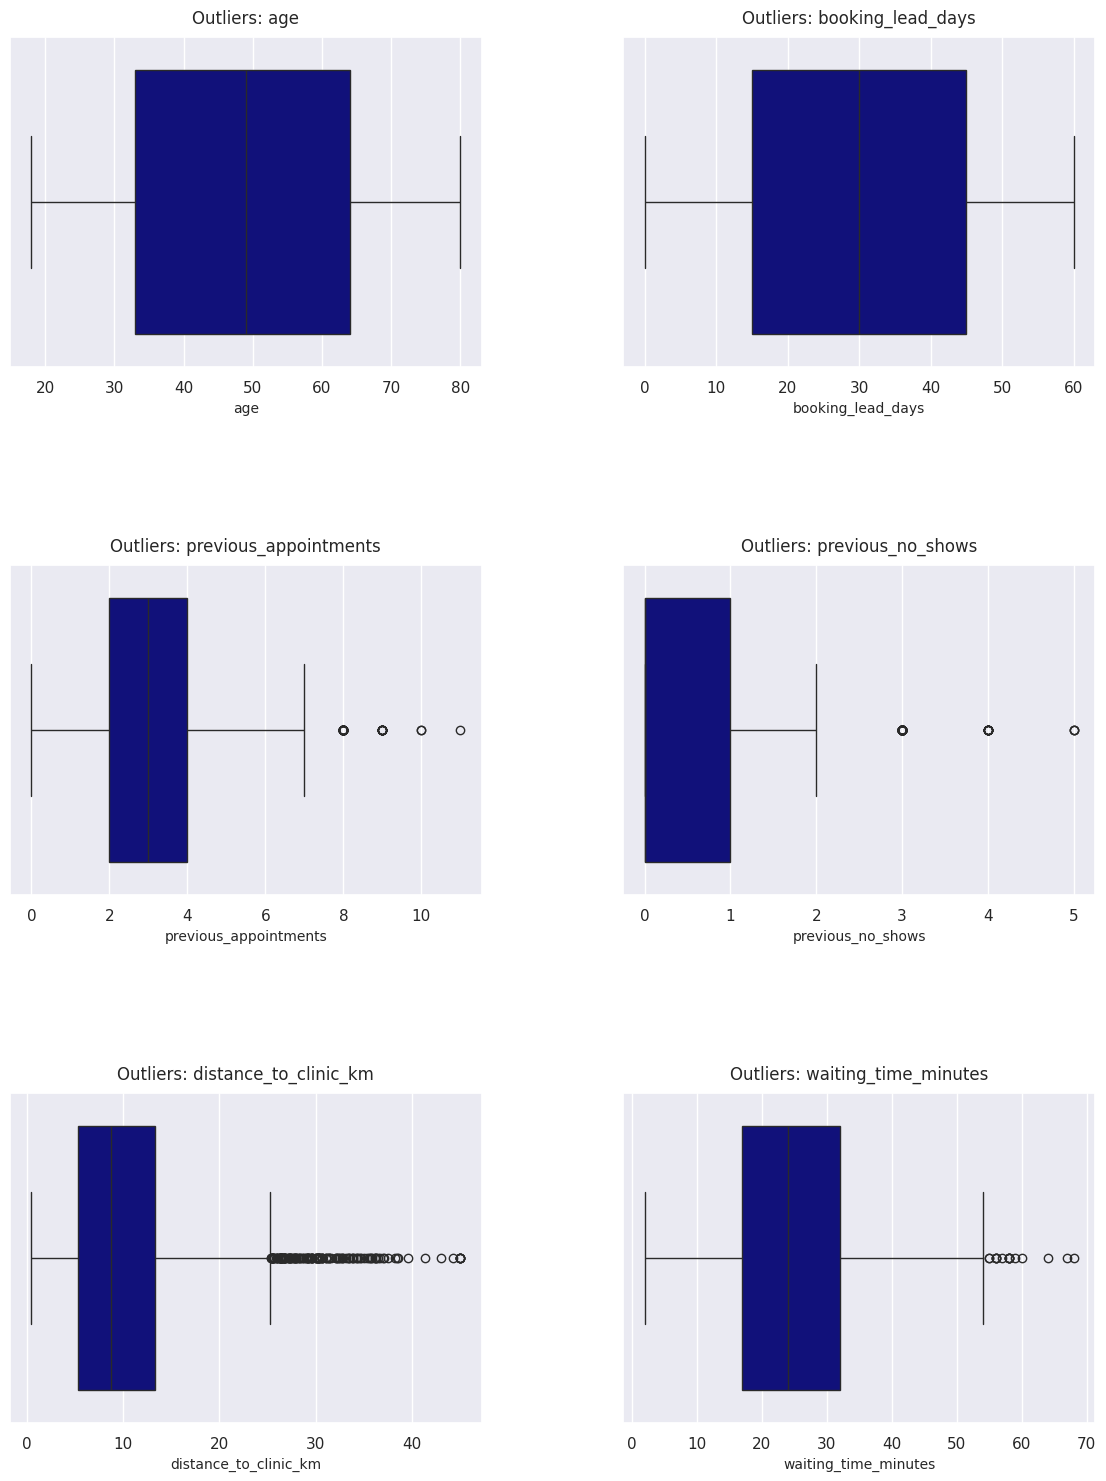

In [ ]:
import math
numeric_columns = [column for column in numeric_columns if column not in ['no_show']]
num_vars = len(numeric_columns)
cols_per_row = 2
rows = math.ceil(num_vars / cols_per_row)
fig, axes = plt.subplots(rows, cols_per_row, figsize=(14, 6 * rows))
axes = axes.flatten()
for i, column in enumerate(numeric_columns):
    sns.boxplot(data=model_health_connect,x=column, ax=axes[i], color='darkblue')
    axes[i].set_title(f"Outliers: {column}", fontsize = 12, pad = 10)
    axes[i].set_xlabel(column, fontsize = 10)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.subplots_adjust(hspace=0.6, wspace=0.3)
plt.show()

#**DATE CONVERSION**

In [ ]:
date_columns = [column
    for column in model_health_connect.columns
                if "date" in str(column).lower()]

print("Potential date columns:")
print(date_columns)
for column in date_columns:
    model_health_connect[column] = pd.to_datetime(model_health_connect[column],errors="coerce")
print("\nDate conversion completed.")

Potential date columns:
['booking_date', 'appointment_date']

Date conversion completed.


#**TIME-BASED FEATURE ENGINEERING**

In [ ]:
if ("booking_date" in model_health_connect.columns and"appointment_date" in model_health_connect.columns):
    model_health_connect["waiting_time_days"] = (model_health_connect["appointment_date"]- model_health_connect["booking_date"]).dt.days
    model_health_connect["appointment_day"] = (model_health_connect["appointment_date"].dt.day_name())
    model_health_connect["appointment_month"] = (model_health_connect["appointment_date"].dt.month)
    model_health_connect["appointment_day_number"] = (model_health_connect["appointment_date"].dt.day)
    print("Waiting time and appointment timing ""features created successfully.")
    display(model_health_connect[["booking_date","appointment_date","waiting_time_days","appointment_day","appointment_month"]].head())
else:
    print("Required booking_date and/or appointment_date ""columns were not found.")

Waiting time and appointment timing features created successfully.


,booking_date,appointment_date,waiting_time_days,appointment_day,appointment_month
0,2025-02-06,2025-02-18,12,Tuesday,2
1,2026-02-25,2026-02-27,2,Friday,2
2,2025-11-16,2025-12-24,38,Wednesday,12
3,2025-07-18,2025-08-28,41,Thursday,8
4,2025-07-09,2025-08-25,47,Monday,8


#**WAITING TIME VALIDATION**

In [ ]:
if "waiting_time_days" in model_health_connect.columns:
    print("Waiting time statistics:")
    display(model_health_connect["waiting_time_days"].describe().to_frame("Waiting Time"))
    negative_waiting = (model_health_connect["waiting_time_days"] < 0).sum()
    print("\nNegative waiting-time records:",negative_waiting)
    if negative_waiting > 0:
        display(model_health_connect[model_health_connect["waiting_time_days"] < 0][["booking_date","appointment_date","waiting_time_days"]].head(20))


Waiting time statistics:


,Waiting Time
count,4737.000000
mean,29.639012
std,17.412842
min,0.000000
25%,15.000000
50%,30.000000
75%,45.000000
max,60.000000



Negative waiting-time records: 0


#**TARGET DISTRIBUTION**

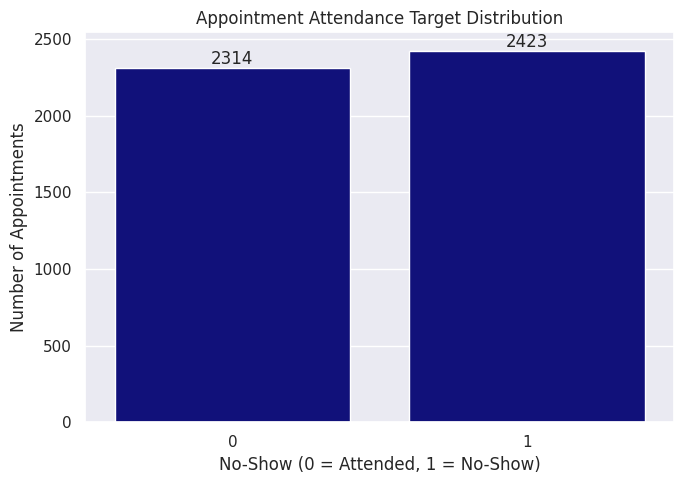

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=model_health_connect,x='no_show', color = 'darkblue')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Appointment Attendance Target Distribution")
plt.xlabel("No-Show (0 = Attended, 1 = No-Show)")
plt.ylabel("Number of Appointments")
plt.tight_layout()
plt.show()

#**WAITING TIME VS NO-SHOW**

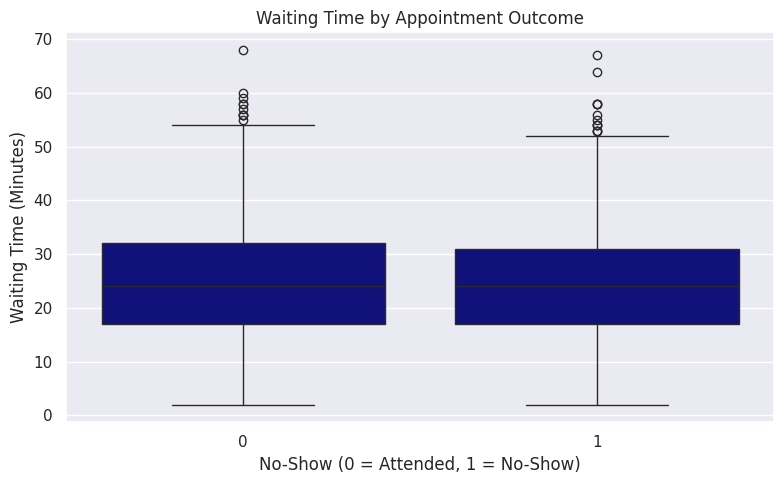

In [ ]:
if "waiting_time_minutes" in model_health_connect.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=model_health_connect,x="no_show",y="waiting_time_minutes", color = 'darkblue')
    plt.title("Waiting Time by Appointment Outcome")
    plt.xlabel("No-Show (0 = Attended, 1 = No-Show)")
    plt.ylabel("Waiting Time (Minutes)")
    plt.tight_layout()
    plt.show()


#**PREVIOUS NO-SHOWS VS CURRENT OUTCOME**

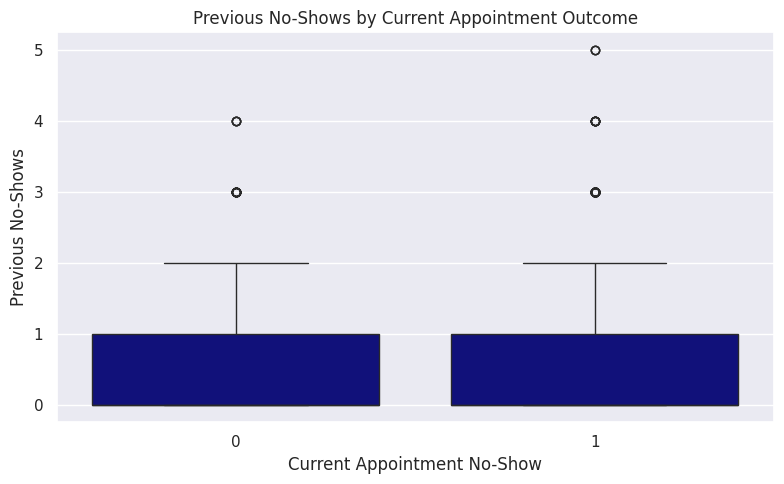

In [ ]:
if "previous_no_shows" in model_health_connect.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=model_health_connect,x="no_show",y="previous_no_shows", color = 'darkblue')
    plt.title("Previous No-Shows by Current Appointment Outcome")
    plt.xlabel("Current Appointment No-Show")
    plt.ylabel("Previous No-Shows")
    plt.tight_layout()
    plt.show()

#**NUMERICAL CORRELATION**

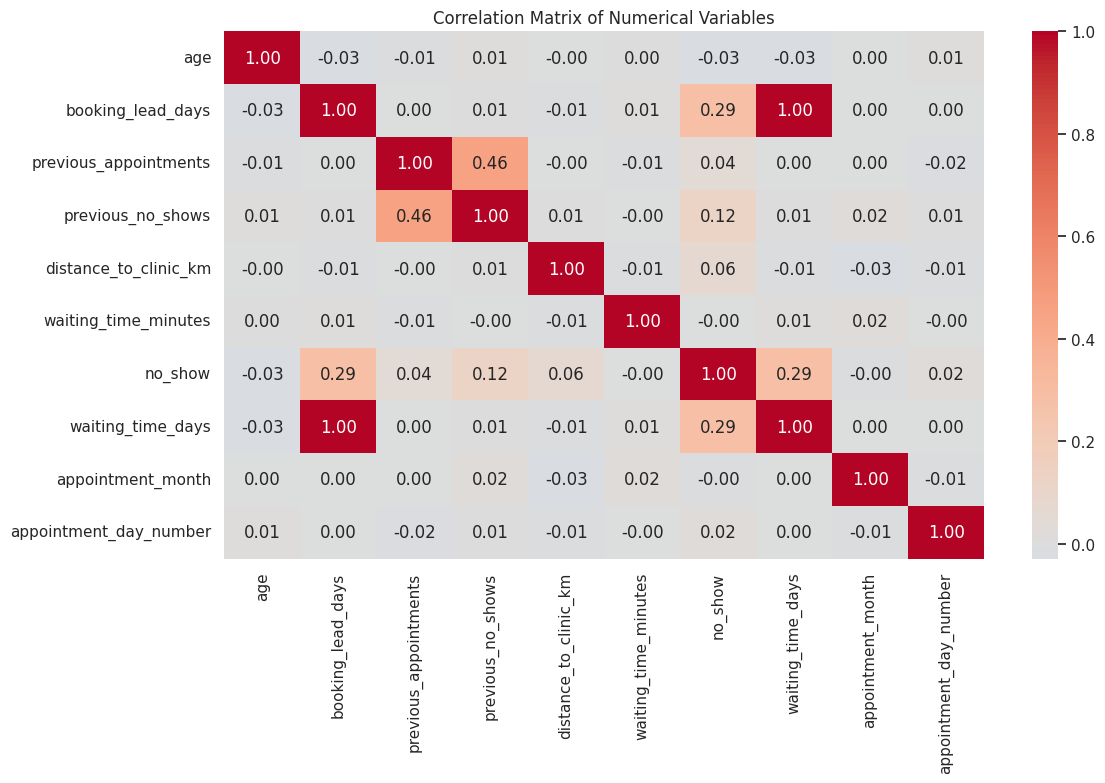

In [ ]:
numeric_model_health_connect = model_health_connect.select_dtypes(include=np.number)
if numeric_model_health_connect.shape[1] > 1:
    plt.figure(figsize=(12, 8))
    sns.heatmap(numeric_model_health_connect.corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0)
    plt.title("Correlation Matrix of Numerical Variables")
    plt.tight_layout()
    plt.show()


#**FEATURE SELECTION**

In [ ]:
candidate_features = [
    # Historical attendance
    "previous_no_shows",

    # Appointment timing
    "waiting_time_minutes",
    "appointment_day",
    "appointment_date",

    # HealthConnect variables below:
    #
    # "reminder_sent",
    # "appointment_type",
    # "booking_date",
    # "distance_to_clinic_km",
    # "age",
    # "gender",
    ]

available_features = [feature
    for feature in candidate_features
    if feature in model_health_connect.columns]
missing_features = [feature
    for feature in candidate_features
    if feature not in model_health_connect.columns]
print("Available candidate features:")
for feature in available_features:
    print("-", feature)
print("\nCandidate features not found:")
for feature in missing_features:
    print("-", feature)

Available candidate features:
- previous_no_shows
- waiting_time_minutes
- appointment_day
- appointment_date

Candidate features not found:


#**TARGET LEAKAGE PROTECTION**

In [ ]:
leakage_columns = [outcome_col,"no_show"]
possible_post_outcome_columns = ["final_status","attendance_confirmation","post_appointment_status","attendance_status","final_outcome"]
for column in possible_post_outcome_columns:
    if column in model_health_connect.columns:
        leakage_columns.append(column)
print("Variables excluded because of potential leakage:")
for column in leakage_columns:
    if column in model_health_connect.columns:
        print("-", column)

Variables excluded because of potential leakage:
- appointment_outcome
- no_show


#**REMOVE RAW DATES AND IDENTIFIERS**

In [ ]:
raw_date_columns = [column
    for column in ["booking_date","appointment_date"]
    if column in model_health_connect.columns]
excluded_columns = (leakage_columns + raw_date_columns)
excluded_columns = list(dict.fromkeys(excluded_columns))
print("Excluded columns:")
for column in excluded_columns:
    print("-", column)


Excluded columns:
- appointment_outcome
- no_show
- booking_date
- appointment_date


#**FINAL FEATURE LIST**

In [ ]:
final_features = [feature
    for feature in available_features
    if feature not in excluded_columns]
print("Final modelling features:")
for number, feature in enumerate(final_features,start=1):
    print(f"{number}. {feature}")
print("\nNumber of final features:",len(final_features))

Final modelling features:
1. previous_no_shows
2. waiting_time_minutes
3. appointment_day

Number of final features: 3


#**FEATURE VALIDATION**

In [ ]:
if len(final_features) == 0:
    raise ValueError("No valid modelling features have been selected. ""Review candidate_features using the actual ""HealthConnect dataset and Data Dictionary.")
X = model_health_connect[final_features].copy()
y = model_health_connect["no_show"].copy()
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4737, 3)
y shape: (4737,)


#**FEATURE DOCUMENTATION**

In [ ]:
feature_documentation = []
for column in final_features:
    feature_documentation.append({"Feature": column,"Data Type": str(model_health_connect[column].dtype),
        "Missing Count": (model_health_connect[column].isna().sum()),
        "Missing Percentage": round(model_health_connect[column].isna().mean() * 100,2),
        "Unique Values": (model_health_connect[column].nunique(dropna=True)),
        "ML Role": "Candidate Input Feature",
        "Leakage Status": "Reviewed",
        "Availability": ('Must be available before prediction')})
feature_documentation = pd.DataFrame(feature_documentation)
display(feature_documentation)

,Feature,Data Type,Missing Count,Missing Percentage,Unique Values,ML Role,Leakage Status,Availability
0,previous_no_shows,int64,0,0.0,6,Candidate Input Feature,Reviewed,Must be available before prediction
1,waiting_time_minutes,float64,0,0.0,63,Candidate Input Feature,Reviewed,Must be available before prediction
2,appointment_day,object,0,0.0,7,Candidate Input Feature,Reviewed,Must be available before prediction


#**TRAIN/TEST SPLIT**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).mul(100).round(2).rename(index={0: "Attended",1: "No-Show"}).to_frame("Percentage"))
print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).mul(100).round(2).rename(index={0: "Attended",1: "No-Show"}).to_frame("Percentage"))

Training set shape: (3789, 3)
Testing set shape: (948, 3)

Training target distribution:


,Percentage
no_show,
No-Show,51.15
Attended,48.85



Testing target distribution:


,Percentage
no_show,
No-Show,51.16
Attended,48.84


#**NUMERICAL AND CATEGORICAL FEATURES**

In [ ]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object","category","bool","string"]).columns.tolist()
print("Numerical features:")
for feature in numeric_features:
    print("-", feature)
print("\nCategorical features:")
for feature in categorical_features:
    print("-", feature)

Numerical features:
- previous_no_shows
- waiting_time_minutes

Categorical features:
- appointment_day


#**NUMERICAL PREPROCESSING**

In [ ]:
numeric_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])

#**CATEGORICAL PREPROCESSING**
##**ONE-HOT ENCODING**

In [ ]:
categorical_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
print("Categorical preprocessing pipeline created.")
print("OneHotEncoder will convert categorical ""variables into numerical indicator features.")

Categorical preprocessing pipeline created.
OneHotEncoder will convert categorical variables into numerical indicator features.


#**COMBINED PREPROCESSING PIPELINE**

In [ ]:
preprocessor = ColumnTransformer(transformers=[("numeric",numeric_transformer,numeric_features),("categorical",categorical_transformer,categorical_features)],remainder='drop')
print("Combined numerical and categorical ""preprocessing pipeline created successfully.")

Combined numerical and categorical preprocessing pipeline created successfully.


#**DUMMY BASELINE MODEL**

In [ ]:
dummy_model = Pipeline(steps=[("preprocessor",preprocessor),("classifier",DummyClassifier(strategy="most_frequent"))])
dummy_model.fit(X_train,y_train)
dummy_predictions = dummy_model.predict(X_test)
print("Dummy baseline model trained successfully.")

Dummy baseline model trained successfully.


#**LOGISTIC REGRESSION BASELINE**

In [ ]:
logistic_model = Pipeline(steps=[("preprocessor",preprocessor),("classifier",LogisticRegression(max_iter=1000,random_state=42))])
logistic_model.fit(X_train,y_train)
logistic_predictions = (logistic_model.predict(X_test))
logistic_probabilities = (logistic_model.predict_proba(X_test)[:, 1])
print("Logistic Regression baseline model ""trained successfully.")

Logistic Regression baseline model trained successfully.


#**MODEL EVALUATION FUNCTION**

In [ ]:
def evaluate_model(model_name,y_true,predictions,probabilities=None):
    results = {"Model": model_name,"Accuracy": accuracy_score(y_true,predictions),
        "Precision": precision_score(y_true,predictions,zero_division=0),
        "Recall": recall_score(y_true,predictions,zero_division=0),
        "F1 Score": f1_score(y_true,predictions,zero_division=0)}
    if probabilities is not None:
        results["ROC-AUC"] = roc_auc_score(y_true,probabilities)
    else:
        results["ROC-AUC"] = np.nan
    return results

#**EVALUATE BASELINE MODELS**

In [ ]:
dummy_results = evaluate_model("Dummy Classifier",y_test,dummy_predictions)
logistic_results = evaluate_model("Logistic Regression",y_test,logistic_predictions,logistic_probabilities)
model_results = pd.DataFrame([dummy_results,logistic_results])
display( model_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Dummy Classifier,0.5116,0.5116,1.0000,0.6769,NaN
1,Logistic Regression,0.5390,0.5538,0.5093,0.5306,0.5433


#**CLASSIFICATION REPORT**

In [ ]:
print("Logistic Regression Classification Report")
print(classification_report(y_test,logistic_predictions,target_names=["Attended","No-Show"],zero_division=0))

Logistic Regression Classification Report
              precision    recall  f1-score   support

    Attended       0.53      0.57      0.55       463
     No-Show       0.55      0.51      0.53       485

    accuracy                           0.54       948
   macro avg       0.54      0.54      0.54       948
weighted avg       0.54      0.54      0.54       948



#**CONFUSION MATRIX**

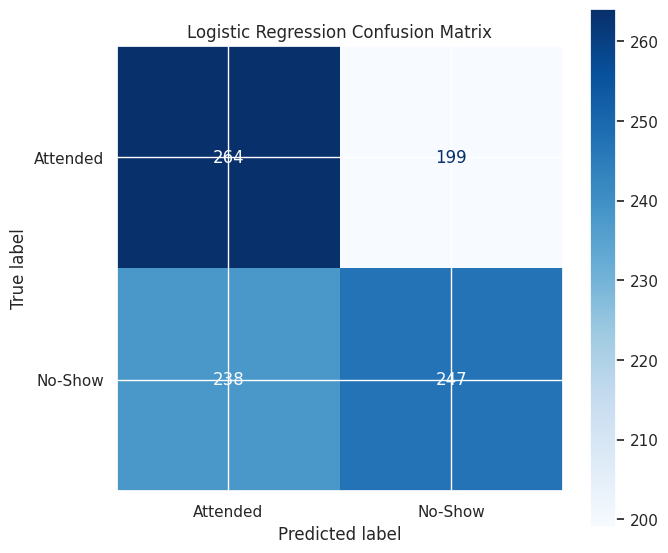

In [ ]:
cm = confusion_matrix(y_test,logistic_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Attended","No-Show"])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax,cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

#**LOGISTIC REGRESSION COEFFICIENTS**

In [ ]:
fitted_preprocessor = (logistic_model.named_steps["preprocessor"])
fitted_classifier = (logistic_model.named_steps["classifier"])
feature_names = (fitted_preprocessor.get_feature_names_out())
coefficients = (fitted_classifier.coef_[0])
coefficient_table = pd.DataFrame({"Feature": feature_names,"Coefficient": coefficients})
coefficient_table["Absolute Coefficient"] = (coefficient_table["Coefficient"].abs())
coefficient_table = coefficient_table.sort_values("Absolute Coefficient",ascending=False)
display(coefficient_table.head(20))

,Feature,Coefficient,Absolute Coefficient
0,numeric__previous_no_shows,0.277071,0.277071
5,categorical__appointment_day_Sunday,0.161080,0.161080
2,categorical__appointment_day_Friday,-0.113234,0.113234
4,categorical__appointment_day_Saturday,-0.065998,0.065998
8,categorical__appointment_day_Wednesday,0.057664,0.057664
7,categorical__appointment_day_Tuesday,-0.032442,0.032442
1,numeric__waiting_time_minutes,-0.023170,0.023170
3,categorical__appointment_day_Monday,0.021915,0.021915
6,categorical__appointment_day_Thursday,0.013588,0.013588


#**TOP LOGISTIC REGRESSION COEFFICIENTS**

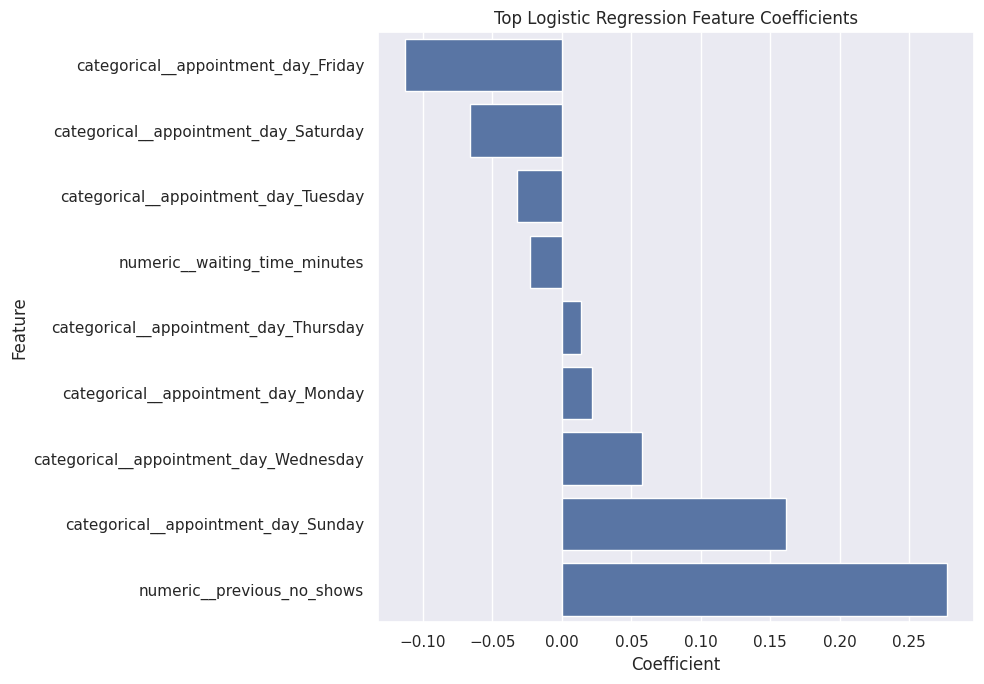

In [ ]:
top_coefficients = (coefficient_table.head(15).sort_values("Coefficient"))
plt.figure(figsize=(10, 7))
sns.barplot(data=top_coefficients,x="Coefficient",y="Feature")
plt.title("Top Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#**DATA PREPARATION SUMMARY**

In [ ]:
preparation_summary = pd.DataFrame({"Measure": ["Original rows","Rows after outcome filtering","Number of final features","Training rows","Testing rows"],
    "Value": [len(health_connect),len(health_connect[health_connect[outcome_col].isin(model_outcomes)]),len(model_health_connect),len(X_train),len(X_test)]})
display(preparation_summary)


,Measure,Value
0,Original rows,5000
1,Rows after outcome filtering,4737
2,Number of final features,4737
3,Training rows,3789
4,Testing rows,948


#**FINAL DATA QUALITY CHECK**

In [ ]:
print("=" * 70)
print("FINAL DATA QUALITY CHECK")
print("=" * 70)
print("\nFinal modelling dataset shape:")
print(model_health_connect.shape)
print("\nDuplicate rows:")
print(model_health_connect.duplicated().sum())
print("\nMissing values in selected features:")
final_feature_missing = pd.DataFrame({"Missing Count": [X[column].isna().sum()for column in final_features],"Missing Percentage": [round(X[column].isna().mean() * 100,2)for column in final_features]}, index=final_features)
display(final_feature_missing)
print("\nTarget distribution:")
display(y.value_counts().rename(index={0: "Attended",1: "No-Show"}).to_frame("Count"))

FINAL DATA QUALITY CHECK

Final modelling dataset shape:
(4737, 22)

Duplicate rows:
0

Missing values in selected features:


,Missing Count,Missing Percentage
previous_no_shows,0,0.0
waiting_time_minutes,0,0.0
appointment_day,0,0.0



Target distribution:


,Count
no_show,
No-Show,2423
Attended,2314


#**SAVE WEEK 5 OUTPUTS**

In [ ]:
model_health_connect.to_csv("HealthConnect_Week5_Cleaned_Model_Dataset.csv")
ml_ready_dataset = model_health_connect[final_features + ["no_show"]].copy()
ml_ready_dataset.to_csv("HealthConnect_ML_Ready_Dataset.csv")
feature_documentation.to_csv("HealthConnect_Feature_Documentation.csv")
missing_summary.to_csv("HealthConnect_Missing_Value_Report.csv")
model_results.to_csv("HealthConnect_Baseline_Model_Results.csv")
print("=" * 70)
print("WEEK 5 OUTPUTS SAVED SUCCESSFULLY")

WEEK 5 OUTPUTS SAVED SUCCESSFULLY
